# Gradient Boosting: US Firm Characteristics

**Docker image**: `ml4t`

This notebook tests whether nonlinear interactions among 57 monthly firm
characteristics improve on the linear baseline. It evaluates one declared
label at a time across the canonical walk-forward folds. The 2016 holdout
remains sealed for the final selected strategy.

**Learning Objectives**:
- Compare tree capacity and robust loss functions on firm characteristics
- Diagnose checkpoint sensitivity across validation folds
- Use a deterministic CPU recipe that readers can reproduce
- Register every validation configuration for downstream strategy selection

**Book Reference**: Chapter 12, Section 12.2 (GBM Libraries)

**Prerequisites**: `03_financial_features.py`, [`05_linear`](05_linear.ipynb)

In [1]:
"""Gradient boosting with walk-forward cross-validation."""

import warnings

import numpy as np
import polars as pl
import yaml
from IPython.display import Markdown, display
from matplotlib import pyplot as plt

from case_studies.utils.gbm import (
    build_gbm_training_spec,
    gbm_checkpoint_iterations,
    lightgbm_runtime_params,
    load_cached_gbm_config,
    prepare_gbm_folds,
    register_gbm_result,
    resolve_gbm_execution_config,
    train_gbm_config,
)
from case_studies.utils.registry import (
    get_training_dir,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.
SEED = 42

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

gbm_config = setup.get("modeling", {}).get("gbm", {})
DEVICE, MAX_BIN, NUM_THREADS = resolve_gbm_execution_config(gbm_config)
RUNTIME_PARAMS = lightgbm_runtime_params(
    DEVICE,
    num_threads=NUM_THREADS,
    seed=SEED,
)

print(
    f"Case study: {CASE_STUDY_ID} | Device: {DEVICE} | "
    f"threads: {NUM_THREADS} | max_bin: {MAX_BIN} | seed: {SEED}"
)

Case study: us_firm_characteristics | Device: cpu | threads: 8 | max_bin: 63 | seed: 42


## 1. Load Data and Model Configs

GBM configs are defined in `config/training/{label}.yaml` under the `gbm` key.
Each name resolves to a shared LightGBM preset. Numerical parameters remain in
the portable training identity; device and thread count are recorded as runtime
provenance.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits[: MAX_FOLDS or None]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 804,530 rows × 57 features
Label: fwd_ret_1m | Task: regression | Folds: 10


The configuration table exposes the capacity, objective, and checkpoint budget
before fitting. The regression labels use five leaf counts crossed with three
losses; the classification label uses one binary objective per leaf count.

In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="gbm")

config_grid = pl.DataFrame(
    {
        "config": [cfg["config_name"] for cfg in configs],
        "leaves": [cfg["params"].get("num_leaves", 31) for cfg in configs],
        "objective": [cfg["params"].get("objective", "regression") for cfg in configs],
        "trees": [cfg.get("max_iterations", 500) for cfg in configs],
    }
)
print(f"Grid: {len(configs)} configs × {len(splits)} folds = {len(configs) * len(splits)} fits")
config_grid

Grid: 15 configs × 10 folds = 150 fits


config,leaves,objective,trees
str,i64,str,i64
"""default_mse""",31,"""regression""",500
"""default_mae""",31,"""regression_l1""",500
"""default_huber""",31,"""huber""",500
"""leaves_7_mse""",7,"""regression""",500
"""leaves_7_mae""",7,"""regression_l1""",500
…,…,…,…
"""leaves_31_mae""",31,"""regression_l1""",500
"""leaves_31_huber""",31,"""huber""",500
"""leaves_63_mse""",63,"""regression""",500


## 2. Prepare CV Folds

GBM folds use LightGBM's native float32 precision and retain missing feature
values for tree-based handling. Classification fits the discrete target, while
validation IC uses the continuous return from which that target was derived.

In [6]:
dataset_pd = dataset.to_pandas()
fold_data = prepare_gbm_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
    eval_label_col=mds.eval_label_col,
    seed=SEED,
)

for f in fold_data:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

expected_keys = pl.concat(
    [
        pl.DataFrame(
            {
                date_col: fold["dates"],
                entity_col: fold["entities"],
                "fold": np.full(fold["n_val"], fold["fold"], dtype=np.int32),
            }
        )
        for fold in fold_data
    ]
)
if expected_keys.n_unique(subset=[date_col, entity_col, "fold"]) != expected_keys.height:
    raise ValueError("Validation data contains duplicate timestamp/entity/fold keys")

  Fold 0: train=282,957  val=22,646
  Fold 1: train=291,956  val=23,236
  Fold 2: train=297,570  val=24,092
  Fold 3: train=302,382  val=24,759
  Fold 4: train=304,305  val=24,870
  Fold 5: train=307,854  val=25,285
  Fold 6: train=314,211  val=25,523
  Fold 7: train=318,921  val=25,834
  Fold 8: train=321,953  val=26,885
  Fold 9: train=320,010  val=28,878


## 3. Train All Configs

For each config, train one LightGBM model per fold to `max_iterations` trees.
Cross-sectional IC is evaluated at checkpoints (every 50 iterations) to
reveal whether additional trees improve or erode validation performance.

The registry specification includes every declared numerical input, while the
execution backend is stored separately so readers can reproduce the same identity.

In [7]:
def _training_spec(cfg):
    return build_gbm_training_spec(
        cfg,
        label_col=label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        feature_names=feature_names,
        splits=splits,
        eval_label_col=mds.eval_label_col,
        task_type=mds.task_type,
        class_values=mds.class_values or None,
        seed=SEED,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )

A complete cached result reconstructs both the ranking metric and learning curve.
Partial runs return to the fit path so the displayed grid never omits a config.

In [8]:
def _cached_result(cfg, spec):
    status = training_run_status(CASE_STUDY_ID, spec)
    if not status.complete or FORCE_RETRAIN:
        if status.partial:
            print(f"  {cfg['config_name']}: retrain, partial state {status.summary()}")
        return None
    try:
        result, _ = load_cached_gbm_config(
            case_study=CASE_STUDY_ID,
            training_spec=spec,
            config_name=cfg["config_name"],
            prediction_split=PREDICTION_SPLIT,
            date_col=date_col,
            entity_col=entity_col,
            eval_col="eval_actual" if mds.eval_label_col else None,
            expected_iterations=gbm_checkpoint_iterations(cfg),
            expected_keys=expected_keys,
        )
    except (FileNotFoundError, ValueError) as exc:
        print(f"  {cfg['config_name']}: retrain, invalid cache: {exc}")
        return None
    print(
        f"  {cfg['config_name']}: IC={result['best_ic']:+.4f} "
        f"at {result['best_iter']} trees (cached)"
    )
    return result

Fresh results are registered immediately after each configuration. This preserves
completed work if a later configuration is interrupted.

In [9]:
def _register_result(result, cfg, spec):
    return register_gbm_result(
        CASE_STUDY_ID,
        result,
        cfg,
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        entry_point="06_gbm",
        date_col=date_col,
        entity_col=entity_col,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        prediction_split=PREDICTION_SPLIT,
        runtime_params=RUNTIME_PARAMS,
        task_type=mds.task_type,
        class_values=mds.class_values or None,
        eval_col="eval_actual" if mds.eval_label_col else None,
        training_spec=spec,
    )

The fit uses the same explicit execution inputs that were hashed above. Each
booster evaluates every checkpoint on the untouched validation slice.

In [10]:
def _fit_result(cfg, spec, train_dir):
    result = train_gbm_config(
        cfg,
        fold_data,
        feature_names=feature_names,
        device=DEVICE,
        num_threads=NUM_THREADS,
        seed=SEED,
        max_bin=MAX_BIN,
        entity_col=entity_col,
        date_col=date_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        save_dir=train_dir,
    )
    _register_result(result, cfg, spec)
    print(
        f"  {result['config_name']}: IC={result['best_ic']:+.4f} "
        f"at {result['best_iter']} trees ({result['elapsed_s']:.0f}s)"
    )
    return result

Run the complete label-specific grid. The cache path is read-only; fresh fits
write one configuration at a time.

In [11]:
results = []
for cfg in configs:
    spec = _training_spec(cfg)
    train_dir = get_training_dir(CASE_STUDY_ID, spec)
    cached = _cached_result(cfg, spec)
    results.append(cached if cached is not None else _fit_result(cfg, spec, train_dir))

  default_mse: IC=+0.0288 at 350 trees (cached)
  default_mae: IC=+0.0809 at 50 trees (cached)
  default_huber: IC=+0.0348 at 50 trees (cached)


  leaves_7_mse: IC=+0.0256 at 500 trees (cached)
  leaves_7_mae: IC=+0.0821 at 200 trees (cached)
  leaves_7_huber: IC=+0.0353 at 500 trees (cached)


  leaves_15_mse: IC=+0.0269 at 500 trees (cached)
  leaves_15_mae: IC=+0.0829 at 150 trees (cached)
  leaves_15_huber: IC=+0.0362 at 300 trees (cached)


  leaves_31_mse: IC=+0.0276 at 300 trees (cached)
  leaves_31_mae: IC=+0.0832 at 100 trees (cached)
  leaves_31_huber: IC=+0.0368 at 200 trees (cached)


  leaves_63_mse: IC=+0.0321 at 300 trees (cached)
  leaves_63_mae: IC=+0.0829 at 50 trees (cached)
  leaves_63_huber: IC=+0.0351 at 250 trees (cached)


## 4. Grid Results

Each configuration is summarized at its own best checkpoint. The IC leader is
diagnostic: all configurations remain eligible for the downstream strategy sweep,
which ranks validation backtests rather than selecting on IC alone.

In [12]:
results.sort(key=lambda r: r["best_ic"], reverse=True)
best = results[0] if results else None

summary = pl.DataFrame(
    {
        "config": [result["config_name"] for result in results],
        "best_trees": [result["best_iter"] for result in results],
        "ic_mean": [result["best_ic"] for result in results],
        "ic_monthly_std": [result["best_ic_std"] for result in results],
        "cached": [result.get("cached", False) for result in results],
    }
)
summary

config,best_trees,ic_mean,ic_monthly_std,cached
str,i64,f64,f64,bool
"""leaves_31_mae""",100,0.083174,0.086092,true
"""leaves_63_mae""",50,0.082896,0.08755,true
"""leaves_15_mae""",150,0.082858,0.087467,true
"""leaves_7_mae""",200,0.082059,0.088463,true
"""default_mae""",50,0.080924,0.083812,true
…,…,…,…,…
"""leaves_63_mse""",300,0.032129,0.054619,true
"""default_mse""",350,0.028755,0.050841,true
"""leaves_31_mse""",300,0.027646,0.057509,true


### Validation IC across the GBM grid

Monthly dispersion is shown with each mean IC. It measures variation across the
complete validation month series, not a confidence interval.

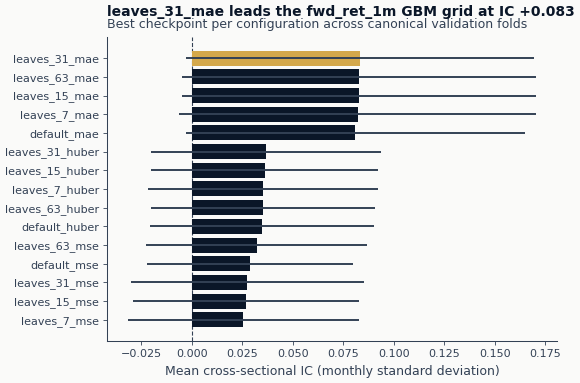

In [13]:
if best:
    plot_summary = summary.sort("ic_mean")
    bar_colors = [
        COLORS["amber"] if name == best["config_name"] else COLORS["blue"]
        for name in plot_summary["config"].to_list()
    ]
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
    ax.barh(
        plot_summary["config"].to_list(),
        plot_summary["ic_mean"].to_list(),
        xerr=plot_summary["ic_monthly_std"].to_list(),
        color=bar_colors,
        ecolor=COLORS["neutral"],
        capsize=2,
    )
    zero_line(ax, axis="x")
    ax.set_xlabel("Mean cross-sectional IC (monthly standard deviation)")
    ax.set_ylabel("")
    add_message_title(
        ax,
        f"{best['config_name']} leads the {PRIMARY_LABEL} GBM grid at IC {best['best_ic']:+.3f}",
        subtitle="Best checkpoint per configuration across canonical validation folds",
    )
    fig.tight_layout()
    plt.show()

## 5. Learning Curves

Checkpoint curves separate a durable plateau from a transient maximum. The chart
shows the five leading configurations so weaker runs do not obscure that comparison.
The leader's ribbon carries the monthly dispersion without stacking five broad bands.

In [14]:
all_curves = pl.DataFrame([c for r in results for c in r["learning_curves"]])
curve_leaders = [result["config_name"] for result in results[:5]]

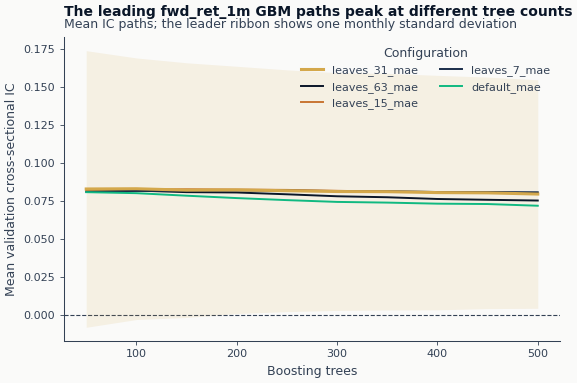

In [15]:
if not all_curves.is_empty():
    palette = [
        COLORS["amber"],
        COLORS["blue"],
        COLORS["copper"],
        COLORS["slate"],
        COLORS["positive"],
    ]
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
    for name, color in zip(curve_leaders, palette, strict=False):
        curve = all_curves.filter(pl.col("config") == name).sort("iteration")
        iterations = curve["iteration"].to_numpy()
        means = curve["ic_mean"].to_numpy()
        stds = curve["ic_std"].to_numpy()
        is_leader = name == best["config_name"]
        ax.plot(
            iterations,
            means,
            color=color,
            label=name,
            linewidth=2.2 if is_leader else 1.4,
            zorder=3 if is_leader else 2,
        )
        if is_leader:
            ax.fill_between(
                iterations,
                means - stds,
                means + stds,
                color=color,
                alpha=0.12,
                linewidth=0,
                zorder=1,
            )
    zero_line(ax, axis="y")
    ax.set_xlabel("Boosting trees")
    ax.set_ylabel("Mean validation cross-sectional IC")
    ax.legend(title="Configuration", frameon=False, ncol=2)
    add_message_title(
        ax,
        f"The leading {PRIMARY_LABEL} GBM paths peak at different tree counts",
        subtitle="Mean IC paths; the leader ribbon shows one monthly standard deviation",
    )
    fig.tight_layout()
    plt.show()

## 6. Registration Complete

Each config was registered immediately after training (see Section 3).
This protects against interruption: all completed configs are already
persisted in `run_log/registry.db`.

In [16]:
print(f"All {len(results)} {PRIMARY_LABEL} configurations are registered for {PREDICTION_SPLIT}.")

All 15 fwd_ret_1m configurations are registered for validation.


## 7. Key Takeaways

In [17]:
if best:
    grid_spread = results[0]["best_ic"] - results[-1]["best_ic"]
    leader_curve = all_curves.filter(pl.col("config") == best["config_name"]).sort("iteration")
    final_ic = float(leader_curve["ic_mean"][-1])
    peak_to_final = best["best_ic"] - final_ic
    display(
        Markdown(
            f"- **Leader:** `{best['config_name']}` leads the `{PRIMARY_LABEL}` grid at "
            f"{best['best_iter']} trees with validation IC {best['best_ic']:+.4f}.\n"
            f"- **Monthly variation:** Its monthly standard deviation is {best['best_ic_std']:.4f}; "
            "the error bar is dispersion, not a confidence interval.\n"
            f"- **Capacity sensitivity:** The best-checkpoint IC spread across the grid is "
            f"{grid_spread:.4f}, and the leader gives back {peak_to_final:.4f} IC by the final "
            "checkpoint.\n"
            "- **Selection boundary:** Every configuration is registered for the downstream "
            "validation backtest sweep; the sealed 2016 holdout remains unopened.\n\n"
            "**Next:** [`07_tabular_dl`](07_tabular_dl.ipynb) tests neural tabular models on the "
            "same label and folds. See Chapter 12, Section 12.2 for gradient boosting."
        )
    )

- **Leader:** `leaves_31_mae` leads the `fwd_ret_1m` grid at 100 trees with validation IC +0.0832.
- **Monthly variation:** Its monthly standard deviation is 0.0861; the error bar is dispersion, not a confidence interval.
- **Capacity sensitivity:** The best-checkpoint IC spread across the grid is 0.0576, and the leader gives back 0.0035 IC by the final checkpoint.
- **Selection boundary:** Every configuration is registered for the downstream validation backtest sweep; the sealed 2016 holdout remains unopened.

**Next:** [`07_tabular_dl`](07_tabular_dl.ipynb) tests neural tabular models on the same label and folds. See Chapter 12, Section 12.2 for gradient boosting.